In [ ]:
## What does Gradient Descent do ?
Gradient Descent is an optimization algorithm used to minimize a loss function by iteratively updating model parameters. 
At each step, it computes the gradient , the direction of steepest increase in loss , and moves in the opposite direction. 
The size of each step is controlled by the learning rate: too high and it overshoots, too low and it converges slowly. 
For convex loss functions like MSE, GD is guaranteed to find the global minimum. 
For non-convex functions like those in neural networks, it may settle at a local minimum or saddle point. 
It is the backbone of nearly all modern ML model training.

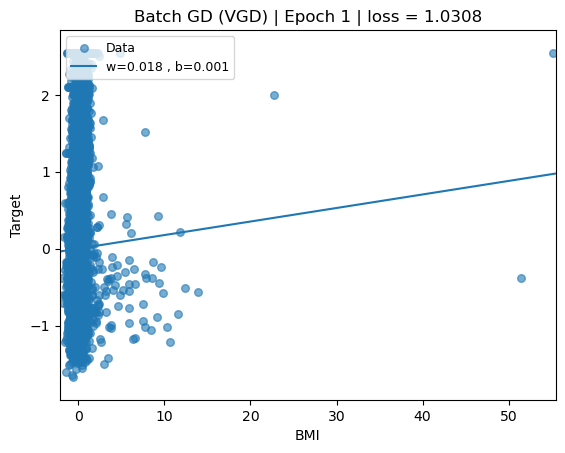

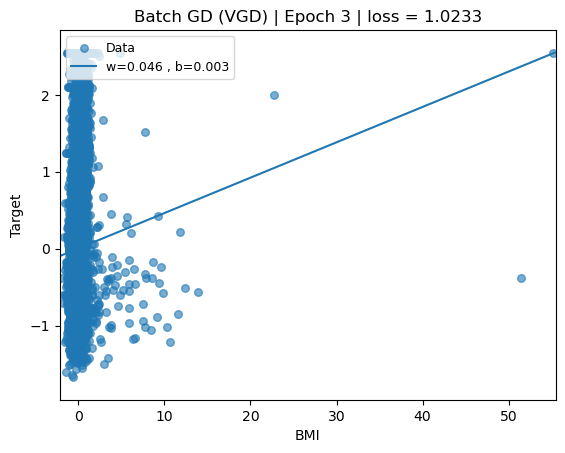

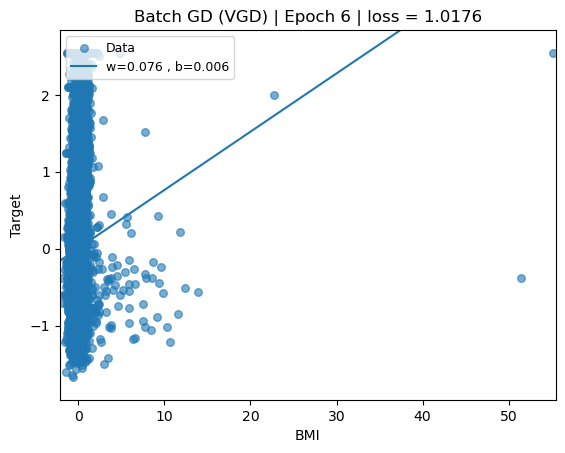

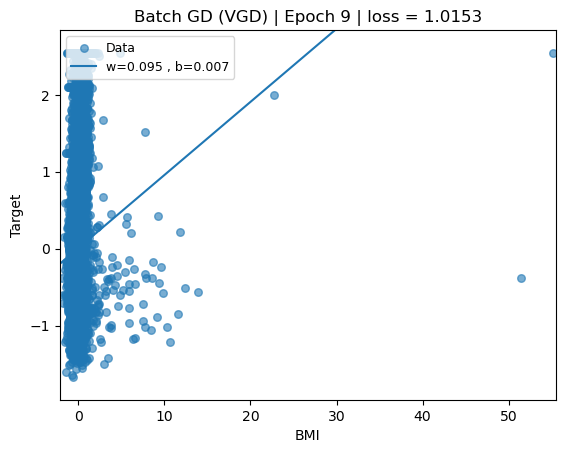

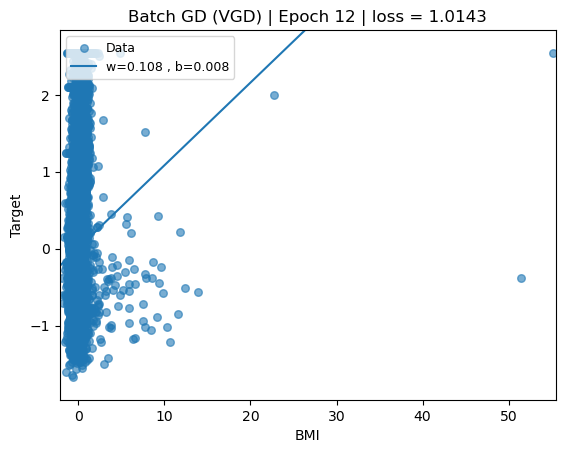

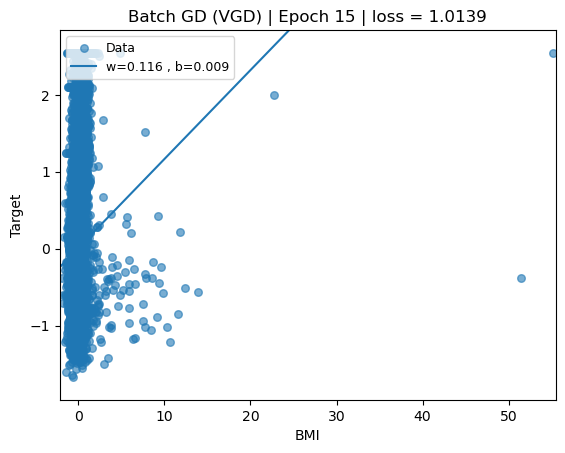

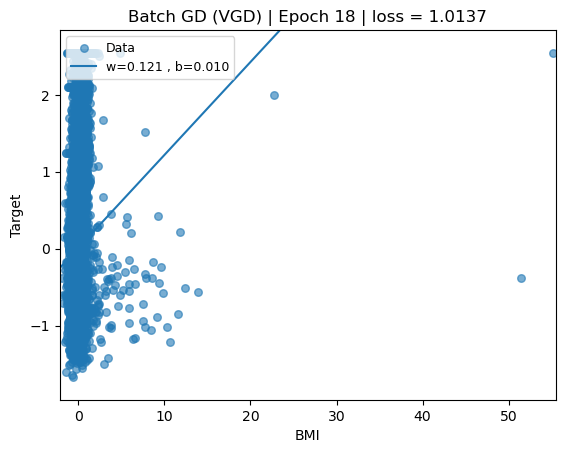

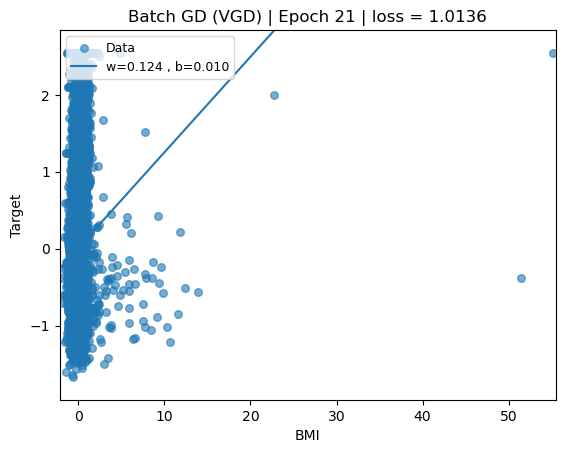

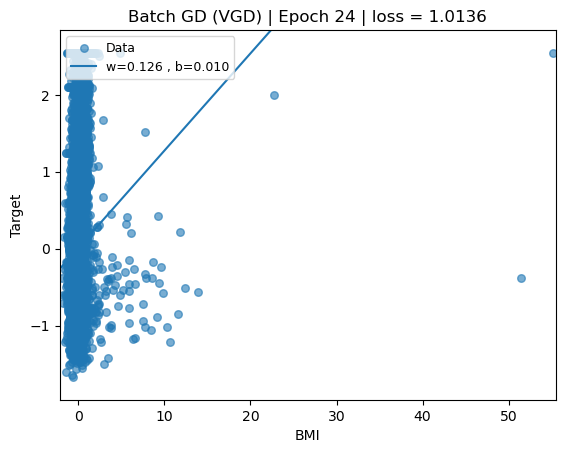

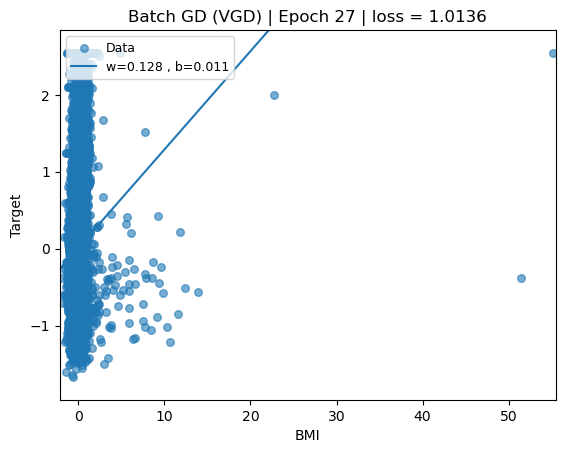

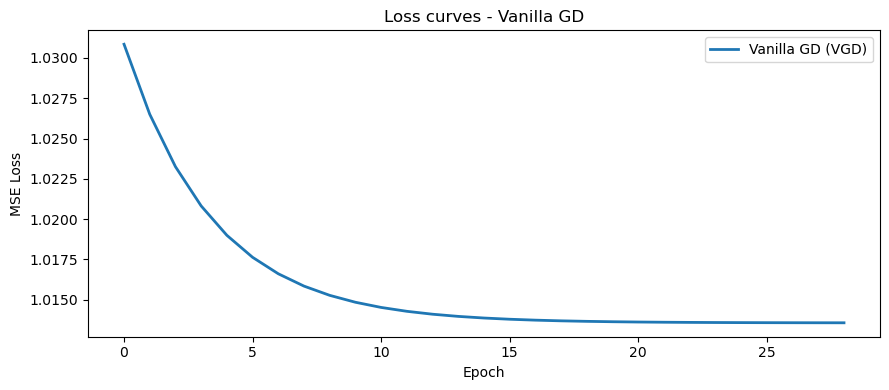

In [37]:
# Get Data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X_full , y = fetch_california_housing(return_X_y = True)
X_full = X_full[:,2:3]
X = StandardScaler().fit_transform(X_full)
y = (y-np.mean(y))/np.std(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.6, random_state=22)

# Build Helper functions
def predict(X,w,b):
    pred = X @ w + b
    return pred

def mse(y_t , y_pred):
    return np.mean((y_t - y_pred) ** 2)

def gradients(X,w,b,y) :
    err = predict(X,w,b) - y
    dW = (2/len(X))*(X.T @ err)
    db = (2/len(X))*np.sum(err)
    return dW , db


def show(X , y , b , w, variant_name , epoch ,loss , pause = 0.3):
    plt.clf()
    x_line = np.linspace(X.min()-0.2 , X.max()+0.2,100).reshape(-1,1)
    y_line = predict(x_line , w, b)
    plt.scatter(X , y , alpha = 0.6 , s = 30 , label = 'Data')
    plt.plot(x_line , y_line , label = f'w={w[0]:.3f} , b={b:.3f}')
    plt.title(f'{variant_name} | Epoch {epoch} | loss = {loss:.4f}')

    plt.xlabel('BMI')
    plt.ylabel('Target')
    plt.legend(loc = 'upper left' , fontsize = 9)
    plt.xlim(X.min()-0.3 , X.max()+0.3)
    plt.ylim(y.min()-0.3 , y.max()+0.3)
    plt.pause(pause)

def vanilla_gd(X , y , lr , epochs):
    w,b = np.zeros(X.shape[1]),0
    losses = []
    for epoch in range(1,epochs,1):
        dW , db = gradients(X,w,b,y)
        w -= lr*dW
        b -= lr*db
        loss = mse(y , predict(X,w,b))
        losses.append(loss)
        if epoch % 3 == 0 or epoch == 1:
            show(X, y, b, w, "Batch GD (VGD)", epoch, loss)
    return w , b , losses

def plot_loss_curves(l_bgd):
    plt.figure(figsize=(9, 4))
    plt.plot(l_bgd,  label='Vanilla GD (VGD)',   linewidth=2)
    # plt.plot(l_sgd,  label='SGD',              linewidth=2, alpha=0.8)
    # plt.plot(l_mbgd, label='Mini-Batch GD',    linewidth=2, alpha=0.8)
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.title('Loss curves - Vanilla GD')
    plt.legend()
    plt.tight_layout()
    plt.show()

plt.ion()   # interactive mode — non-blocking plots
 
w_vgd,  b_vgd,  l_vgd  = vanilla_gd(X_train, y_train,   lr=0.05, epochs=30)
plot_loss_curves(l_vgd)


STOCHASTIC GD (SGD)
Epoch   1 | Loss: 1.3569 | w: 0.6178 | b: -0.1442


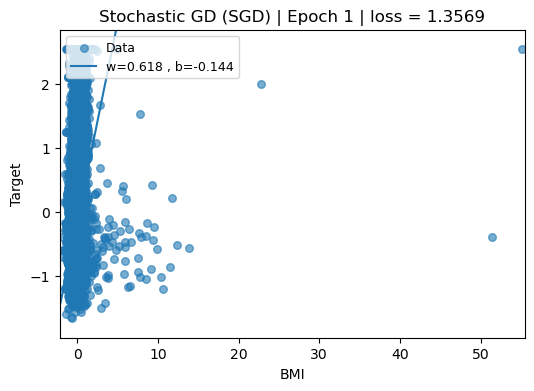

Epoch   2 | Loss: 1.2137 | w: 0.5156 | b: 0.0195
Epoch   3 | Loss: 1.2021 | w: 0.4838 | b: 0.1508


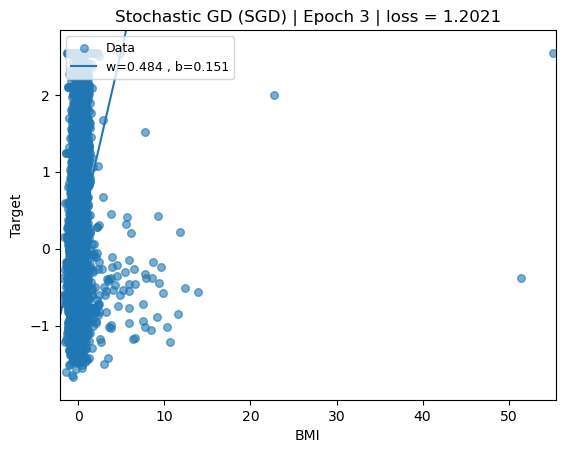

Epoch   4 | Loss: 1.1126 | w: -0.1283 | b: 0.1065
Epoch   5 | Loss: 1.0484 | w: 0.2909 | b: 0.0228
Epoch   6 | Loss: 1.0907 | w: 0.2535 | b: 0.2485


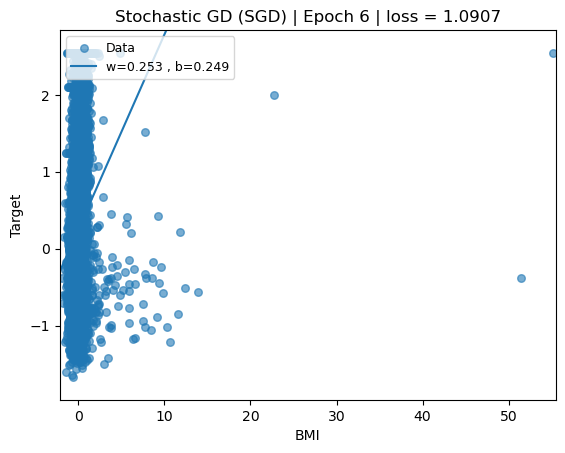

Epoch   7 | Loss: 152.3584 | w: 10.7027 | b: 0.7448
Epoch   8 | Loss: 1.4740 | w: -0.4428 | b: -0.1171
Epoch   9 | Loss: 1.0770 | w: 0.2289 | b: -0.2139


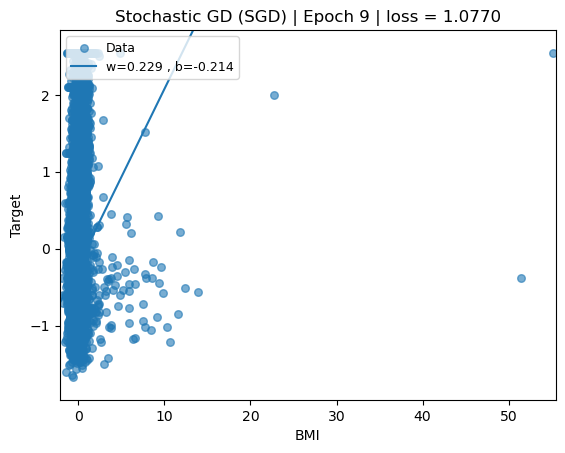

Epoch  10 | Loss: 1.1479 | w: 0.4276 | b: 0.1329
Epoch  11 | Loss: 1.0465 | w: -0.0215 | b: -0.0306
Epoch  12 | Loss: 1.0982 | w: 0.3745 | b: -0.0563


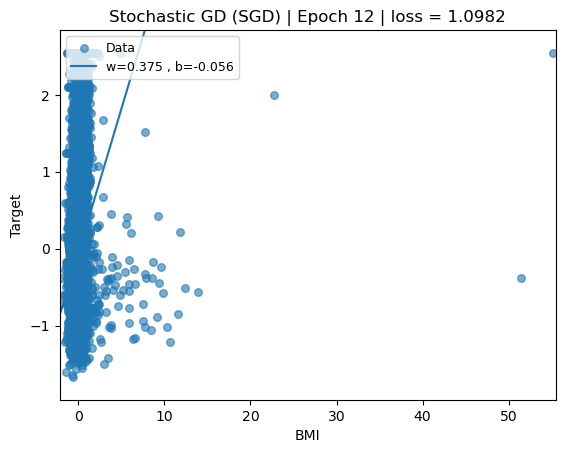

Epoch  13 | Loss: 1.1353 | w: -0.1615 | b: 0.0962
Epoch  14 | Loss: 1.0214 | w: 0.1826 | b: 0.0756
Epoch  15 | Loss: 1.2001 | w: 0.4970 | b: -0.0644


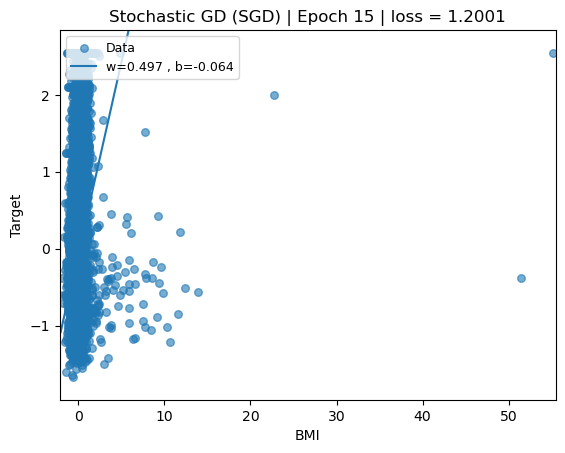

Epoch  16 | Loss: 25.9520 | w: -4.1208 | b: -0.7153
Epoch  17 | Loss: 1.2921 | w: 0.5630 | b: 0.1699
Epoch  18 | Loss: 1.2405 | w: 0.5385 | b: -0.0408


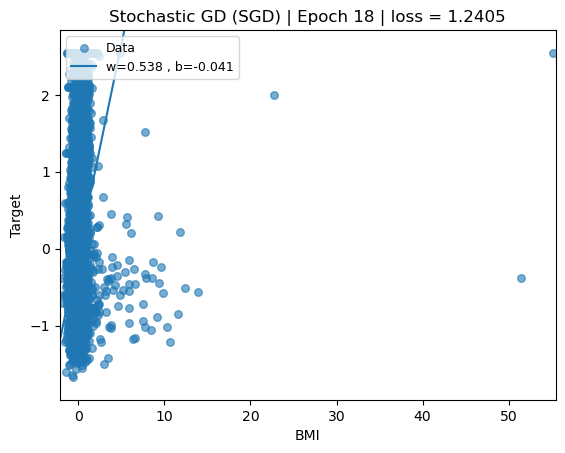

Epoch  19 | Loss: 1.1042 | w: 0.3840 | b: 0.0720
Epoch  20 | Loss: 1.0260 | w: 0.1816 | b: -0.0836
Epoch  21 | Loss: 1.0473 | w: -0.0265 | b: 0.0349


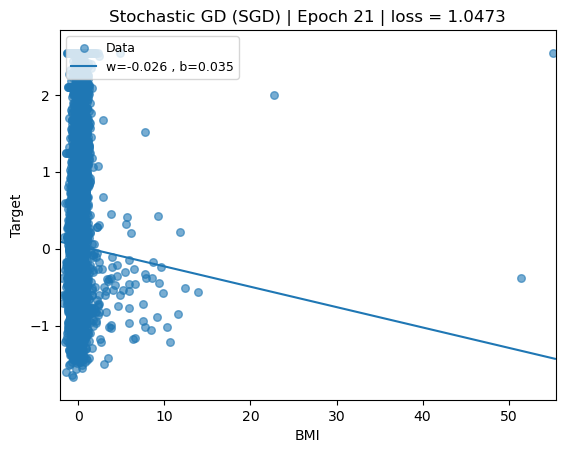

Epoch  22 | Loss: 1.1965 | w: 0.4558 | b: 0.2093
Epoch  23 | Loss: 1.6867 | w: -0.5679 | b: -0.1090
Epoch  24 | Loss: 1.3215 | w: 0.5785 | b: 0.2013


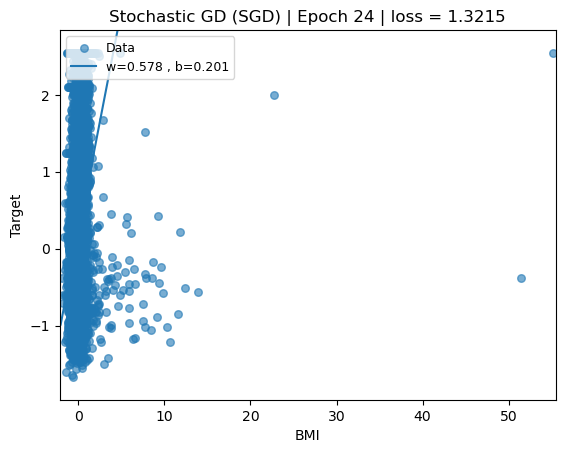

Epoch  25 | Loss: 2.1664 | w: -0.7943 | b: 0.0249
Epoch  26 | Loss: 1.1577 | w: 0.4542 | b: -0.0439
Epoch  27 | Loss: 3.5801 | w: -1.2492 | b: 0.0045


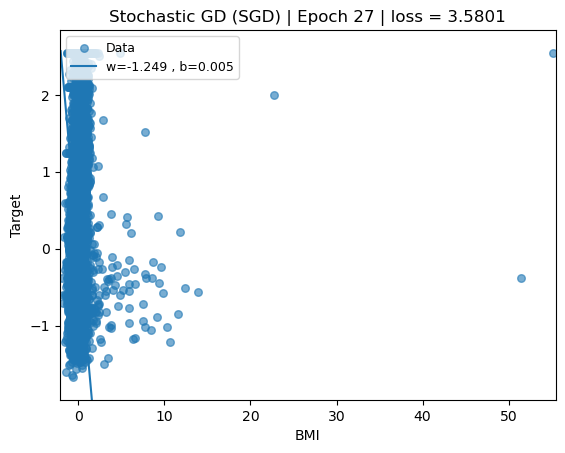

Epoch  28 | Loss: 1.0356 | w: 0.2575 | b: -0.0066
Epoch  29 | Loss: 1.0986 | w: 0.3774 | b: 0.0622
Epoch  30 | Loss: 1.0404 | w: 0.0525 | b: -0.1247


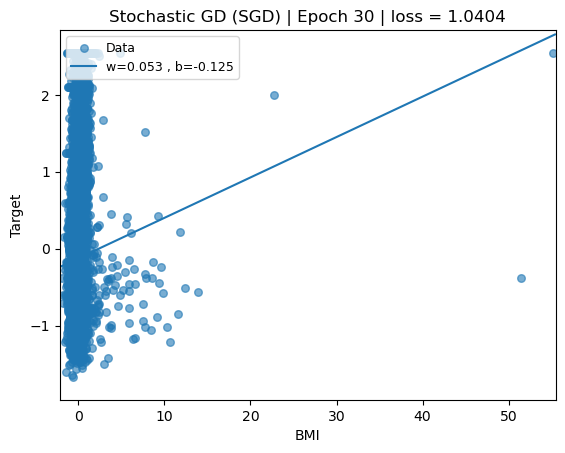

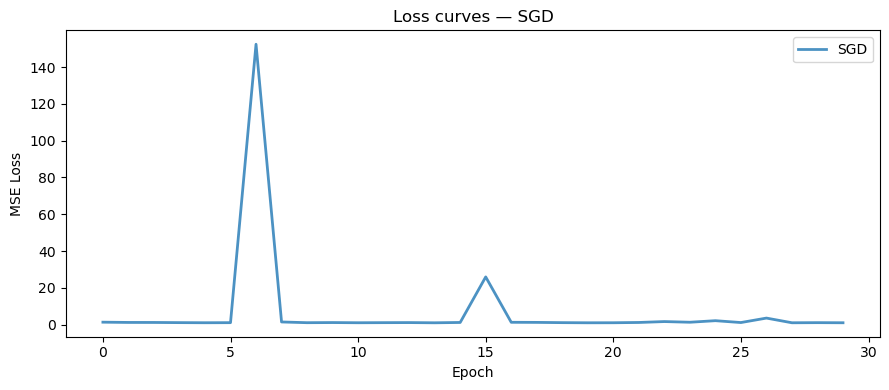

In [40]:
# ── 2. SGD — Stochastic Gradient Descent ────────────────────
def stochastic_gd(X, y, lr=0.01, epochs=30, plot_every=3):
    w, b = np.zeros((X.shape[1],)), 0.0
    losses = []
    plt.figure(figsize=(6, 4))
    print("\n" + "="*50)
    print("STOCHASTIC GD (SGD)")
    print("="*50)
 
    for epoch in range(1, epochs + 1):
        idx = np.random.permutation(len(y))
        for i in idx:
            xi = X[i:i+1]
            yi = y[i:i+1]
            dw, db = gradients(xi, w, b, yi)  # gradient on 1 sample
            w -= lr * dw
            b -= lr * db
 
        loss = mse(y, predict(X, w, b))
        losses.append(loss)
        print(f"Epoch {epoch:3d} | Loss: {loss:.4f} | w: {w[0]:.4f} | b: {b:.4f}")
 
        if epoch % plot_every == 0 or epoch == 1:
            show(X, y, b, w, "Stochastic GD (SGD)", epoch, loss)
 
    plt.close()
    return w, b, losses

# ── Loss curve comparison ─────────────────────────────────────
def plot_loss_curves( l_sgd):
    plt.figure(figsize=(9, 4))
    plt.plot(l_sgd,  label='SGD',              linewidth=2, alpha=0.8)
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.title('Loss curves — SGD')
    plt.legend()
    plt.tight_layout()
    plt.show()
 
# ── Run ──────────────────────────────────────────────────────
plt.ion()   # interactive mode — non-blocking plots
 
w_sgd,  b_sgd,  l_sgd  = stochastic_gd(X_train, y_train, lr=0.01, epochs=30, plot_every=3)
 
plt.ioff()
plot_loss_curves(l_sgd)


MINI-BATCH GD (batch_size=16)
Epoch   1 | Loss: 1.0139 | w: 0.1453 | b: 0.0120


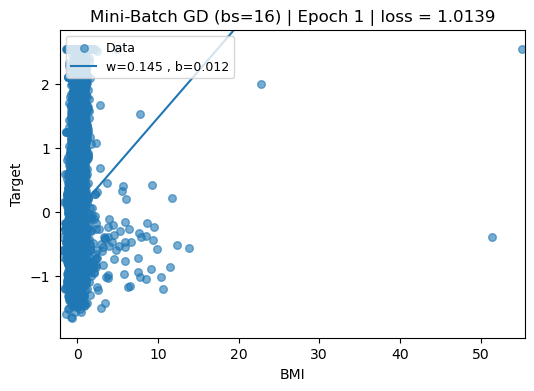

Epoch   2 | Loss: 5.3670 | w: -1.6643 | b: -0.0794
Epoch   3 | Loss: 1.0522 | w: 0.2883 | b: 0.0806


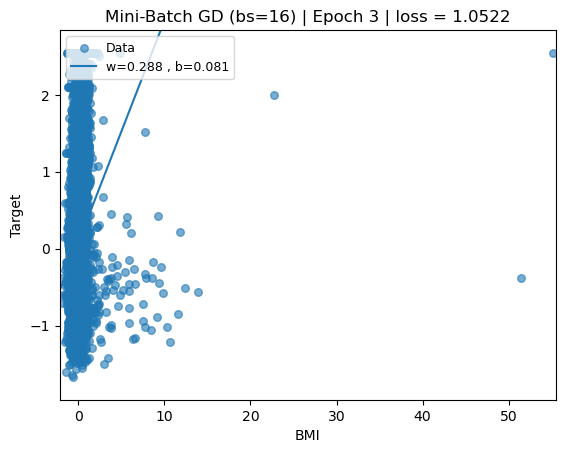

Epoch   4 | Loss: 1.0752 | w: 0.3146 | b: 0.1359
Epoch   5 | Loss: 1.0185 | w: 0.1055 | b: 0.0752
Epoch   6 | Loss: 1.0332 | w: 0.2507 | b: 0.0229


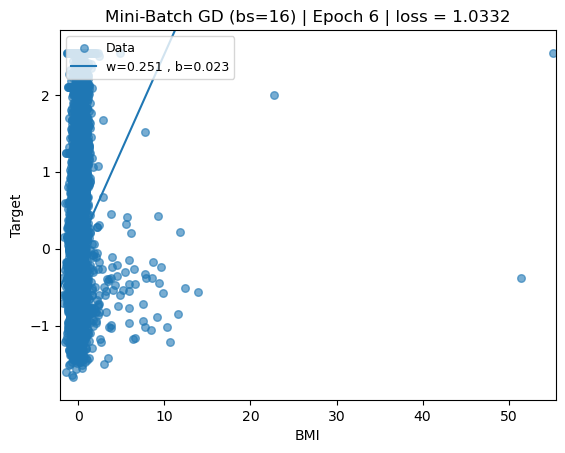

Epoch   7 | Loss: 1.0324 | w: 0.2482 | b: 0.0228
Epoch   8 | Loss: 1.0220 | w: 0.2009 | b: 0.0521
Epoch   9 | Loss: 1.0856 | w: 0.3513 | b: 0.0890


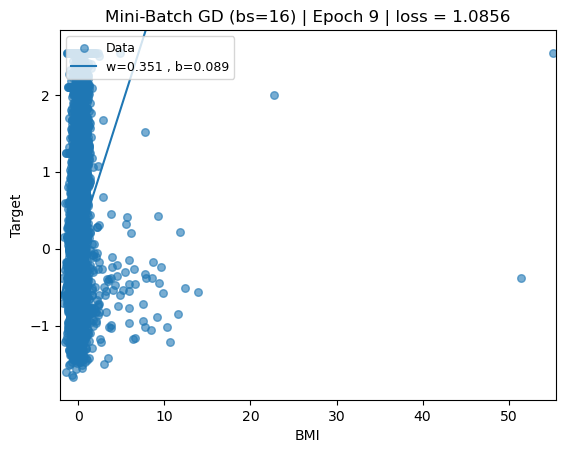

Epoch  10 | Loss: 1.0180 | w: 0.1865 | b: 0.0240
Epoch  11 | Loss: 1.0734 | w: 0.3096 | b: 0.1386
Epoch  12 | Loss: 1.1311 | w: -0.1643 | b: -0.0072


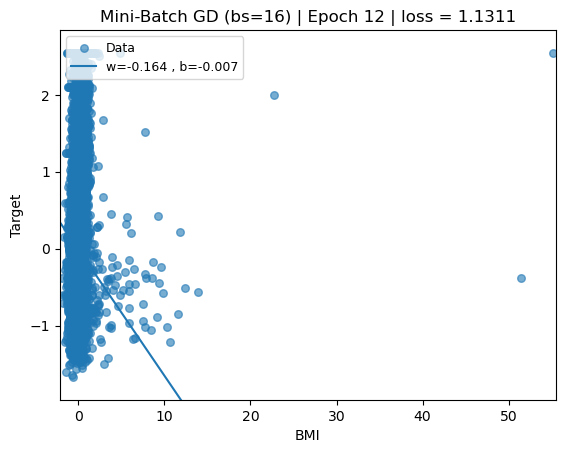

Epoch  13 | Loss: 1.0163 | w: 0.0857 | b: 0.0121
Epoch  14 | Loss: 1.0154 | w: 0.1593 | b: -0.0156
Epoch  15 | Loss: 1.0153 | w: 0.1114 | b: -0.0246


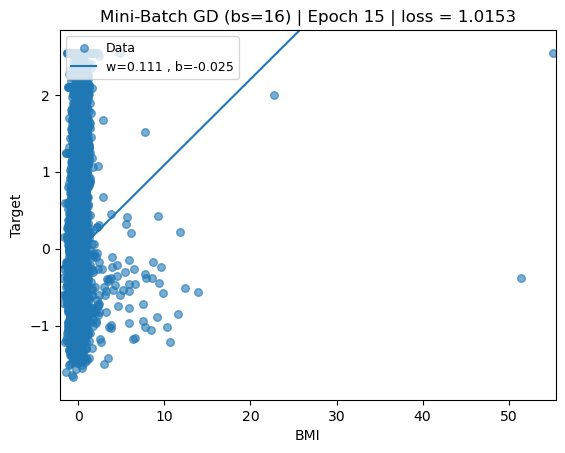

Epoch  16 | Loss: 1.0559 | w: 0.2985 | b: -0.0554
Epoch  17 | Loss: 1.0495 | w: 0.2925 | b: 0.0318
Epoch  18 | Loss: 1.0522 | w: 0.2821 | b: -0.0771


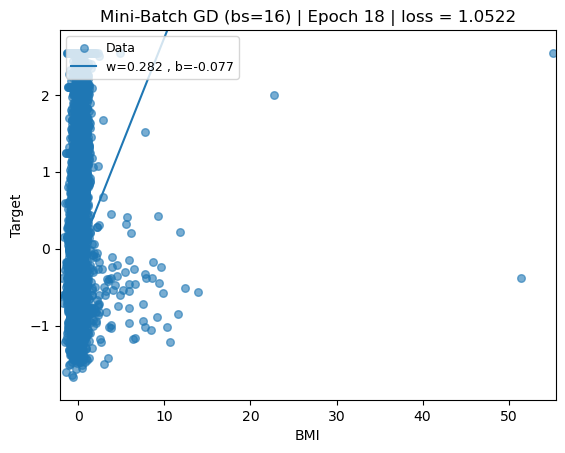

Epoch  19 | Loss: 1.0392 | w: 0.2643 | b: -0.0281
Epoch  20 | Loss: 1.0285 | w: 0.0742 | b: -0.0920
Epoch  21 | Loss: 1.5317 | w: -0.4870 | b: 0.0802


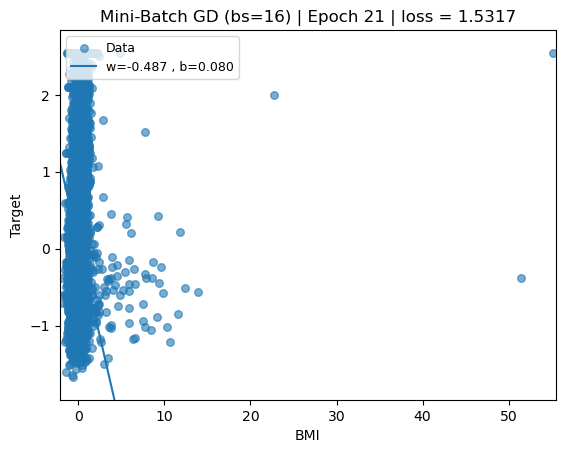

Epoch  22 | Loss: 7.6694 | w: -2.0909 | b: 0.0846
Epoch  23 | Loss: 1.0397 | w: 0.2677 | b: -0.0161
Epoch  24 | Loss: 1.0154 | w: 0.1540 | b: -0.0214


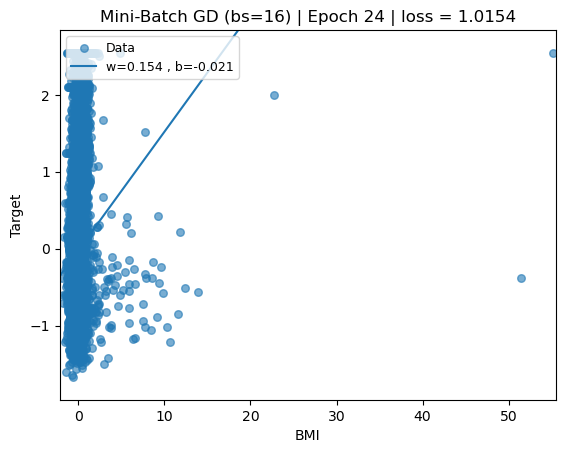

Epoch  25 | Loss: 1.0229 | w: 0.2119 | b: -0.0094
Epoch  26 | Loss: 1.0142 | w: 0.1143 | b: 0.0270
Epoch  27 | Loss: 1.0485 | w: 0.2749 | b: 0.0927


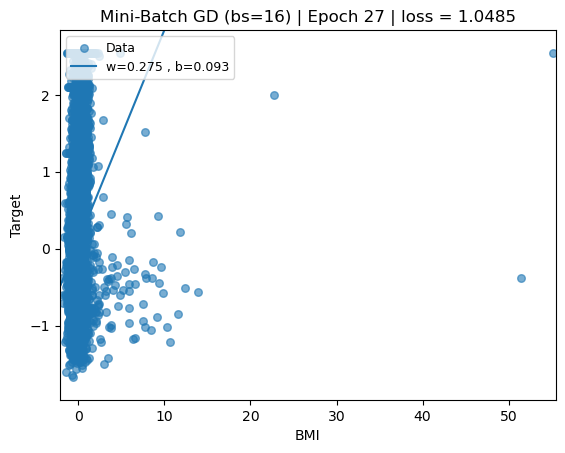

Epoch  28 | Loss: 1.0243 | w: 0.1935 | b: -0.0624
Epoch  29 | Loss: 1.0557 | w: 0.2983 | b: -0.0543
Epoch  30 | Loss: 1.0145 | w: 0.1053 | b: 0.0209


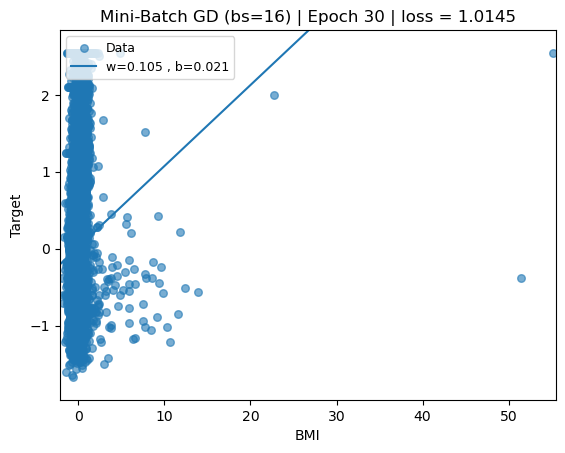

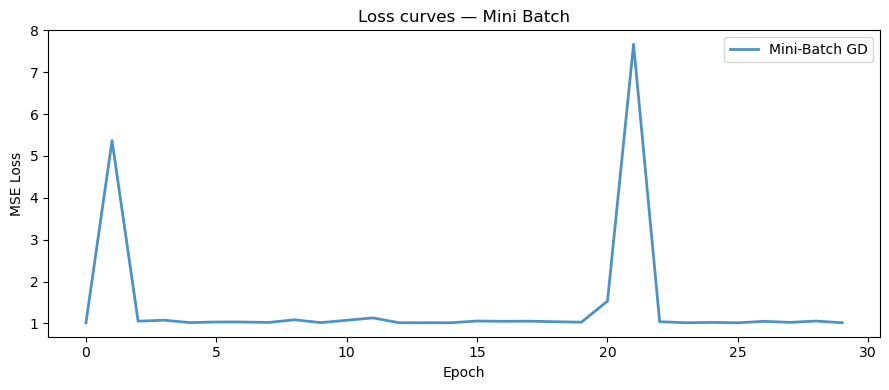

In [44]:
# ── 3. MBGD — Mini-Batch Gradient Descent ───────────────────
def minibatch_gd(X, y, lr=0.03, epochs=30, batch_size=16, plot_every=3):
    w, b = np.zeros((X.shape[1],)), 0.0
    losses = []
    plt.figure(figsize=(6, 4))
    print("\n" + "="*50)
    print(f"MINI-BATCH GD (batch_size={batch_size})")
    print("="*50)
 
    for epoch in range(1, epochs + 1):
        idx = np.random.permutation(len(y))
        for start in range(0, len(y), batch_size):
            sl  = idx[start:start+batch_size]
            Xb, yb = X[sl], y[sl]
            dw, db = gradients(Xb, w, b, yb)  # gradient on mini-batch
            w -= lr * dw
            b -= lr * db
 
        loss = mse(y, predict(X, w, b))
        losses.append(loss)
        print(f"Epoch {epoch:3d} | Loss: {loss:.4f} | w: {w[0]:.4f} | b: {b:.4f}")
 
        if epoch % plot_every == 0 or epoch == 1:
            show(X, y, b, w, f"Mini-Batch GD (bs={batch_size})", epoch, loss)
 
    plt.close()
    return w, b, losses

# ── Loss curve comparison ─────────────────────────────────────
def plot_loss_curves( l_sgd):
    plt.figure(figsize=(9, 4))
    # plt.plot(l_bgd,  label='Batch GD (VGD)',   linewidth=2)
    # plt.plot(l_sgd,  label='SGD',              linewidth=2, alpha=0.8)
    plt.plot(l_mbgd, label='Mini-Batch GD',    linewidth=2, alpha=0.8)
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.title('Loss curves — Mini Batch')
    plt.legend()
    plt.tight_layout()
    plt.show()
 
# ── Run ──────────────────────────────────────────────────────
plt.ion()  
 
w_mbgd, b_mbgd, l_mbgd = minibatch_gd(X_train, y_train, lr=0.03, epochs=30, plot_every=3)
 
plt.ioff()
plot_loss_curves(l_mbgd)